In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from pathlib import Path
import os


In [2]:
from audio_classifier_utils.dataset import CatEmotionDataset
from audio_classifier_utils.models.cnn14 import CatEmotionModel
from audio_classifier_utils.audio_config import AudioConfig

from audio_classifier_utils.data_utils import build_file_list
import random

In [3]:
audio_config = AudioConfig()
audio_config

AudioConfig(sample_rate=16000, window_size=1024, hop_size=320, mel_bins=64, fmin=50, fmax=8000, checkpoint_path='audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth', num_classes=10, augmentation_prob=0.4, target_length=112000)

In [4]:
cnn14_model = CatEmotionModel(audio_config).to("mps")

cnn14_model.load_state_dict(torch.load("models/checkpoints_audio_emotions/best_model_final.pth")['model_state_dict'])

/Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...


/Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/.venv/lib/python3.13/site-packages/torch/serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


Weights loaded successfully!


<All keys matched successfully>

In [5]:
ROOT_DIR_PROCESSED = "human_validation_app/cat_audios_copy_processed/"

files = [
    os.path.join(ROOT_DIR_PROCESSED, f)
    for f in os.listdir(ROOT_DIR_PROCESSED)
    if f.endswith(".mp3")
]

inference_files = [(path, -1) for path in files]

real_dataset = CatEmotionDataset(inference_files, audio_config, train=False)
real_loader = DataLoader(real_dataset, batch_size=32, shuffle=False)
len(real_loader.dataset.samples)

1424

In [6]:
real_dataset[0]

(tensor([-0.0005, -0.0008, -0.0006,  ...,  0.0000,  0.0000,  0.0000]), -1)

In [7]:
cnn14_model.forward(real_dataset[1][0].unsqueeze(0).to("mps"))

tensor([[ -4.4502, -11.1961,  -1.7779,  -2.4115,  -5.1836,  -2.8311,  -0.2155,
          -0.1526,  -7.7968,  -3.6589]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [8]:
from tqdm.auto import tqdm
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [10]:
# 3. The Inference Loop
all_predictions = []
all_probabilities = []

# 🛑 CRITICAL: Disable gradient calculation
with torch.no_grad():
    # Wrap the loader in tqdm
    # We use unit="batch" because each step processes a batch_size of snippets
    pbar = tqdm(real_loader, desc="🧠 Running Emotion Inference", unit="batch")
    
    for batch in pbar:
        # Handling the tuple/list/dict structure
        if isinstance(batch, (tuple, list)):
            inputs = batch[0].to(device)
        elif isinstance(batch, dict):
            inputs = batch['audio'].to(device)
        else:
            inputs = batch.to(device)

        # Forward pass
        logits = cnn14_model(inputs)
        
        # Probabilities and Predictions
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Store results
        all_probabilities.extend(probs.cpu().numpy())
        all_predictions.extend(preds.cpu().tolist())
        
        # Optional: Update the progress bar with a count of total snippets gathered so far
        pbar.set_postfix({"total_snips": len(all_predictions)})

print(f"✅ Inference complete. Processed {len(all_predictions)} snippets.")

🧠 Running Emotion Inference:   0%|          | 0/45 [00:00<?, ?batch/s]

🧠 Running Emotion Inference: 100%|██████████| 45/45 [00:11<00:00,  3.95batch/s, total_snips=1424]

✅ Inference complete. Processed 1424 snippets.


In [11]:
all_predictions[:3], all_probabilities[:3]

([9, 3, 8],
 [array([1.72231070e-04, 1.39520019e-02, 1.89989840e-03, 1.23190123e-03,
         1.06271476e-01, 6.41744658e-02, 7.64900062e-04, 5.95003541e-04,
         2.07334146e-01, 6.03604078e-01], dtype=float32),
  array([9.5227285e-04, 1.4112766e-03, 1.5013050e-03, 7.4602735e-01,
         1.9105716e-01, 2.3006569e-03, 1.0404082e-02, 4.5602426e-02,
         2.6946273e-04, 4.7394761e-04], dtype=float32),
  array([5.9002906e-07, 7.1728820e-05, 1.4759424e-05, 1.0224237e-05,
         2.1740566e-03, 2.4367582e-04, 5.6901318e-04, 4.3787418e-06,
         9.9604994e-01, 8.6162583e-04], dtype=float32)])

In [12]:
idx_to_class = {
    0: 'Angry',
    1: 'Defence',
    2: 'Fighting',
    3: 'Happy',
    4: 'HuntingMind',
    5: 'Mating',
    6: 'MotherCall',
    7: 'Paining',
    8: 'Resting',
    9: 'Warning'
}

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_75872/121977666.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')


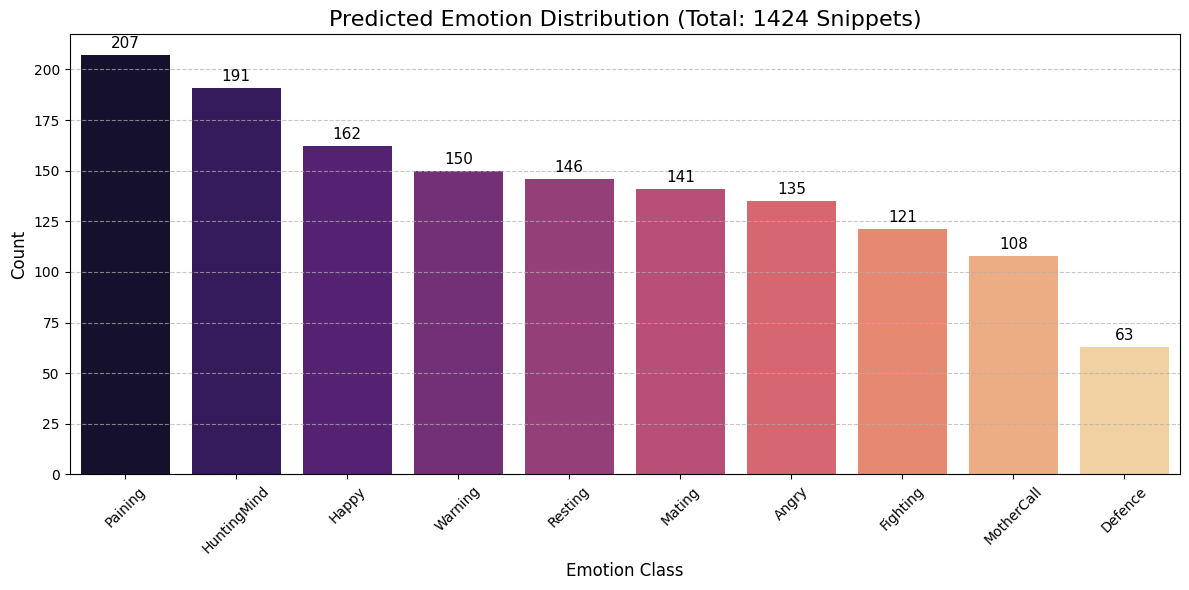

In [13]:
# 1. Map the numeric predictions to their string labels
predicted_labels = [idx_to_class[pred] for pred in all_predictions]

# 2. Create a DataFrame for easy plotting
df_preds = pd.DataFrame({
    'emotion': predicted_labels,
    'confidence': [float(np.max(prob)) for prob in all_probabilities]
})

# 3. Plot the Distribution
plt.figure(figsize=(12, 6))

# We sort by count to make the "dominant" emotions stand out
order = df_preds['emotion'].value_counts().index
ax = sns.countplot(data=df_preds, x='emotion', order=order, palette='magma')

# Add total counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title(f'Predicted Emotion Distribution (Total: {len(df_preds)} Snippets)', fontsize=16)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# 4. Print Summary Stats
print("📊 Emotion Summary:")
print(df_preds['emotion'].value_counts())
print(f"\n💡 Average Model Confidence: {df_preds['confidence'].mean():.2%}")

📊 Emotion Summary:
emotion
Paining        207
HuntingMind    191
Happy          162
Warning        150
Resting        146
Mating         141
Angry          135
Fighting       121
MotherCall     108
Defence         63
Name: count, dtype: int64

💡 Average Model Confidence: 66.18%


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_75872/935029384.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')


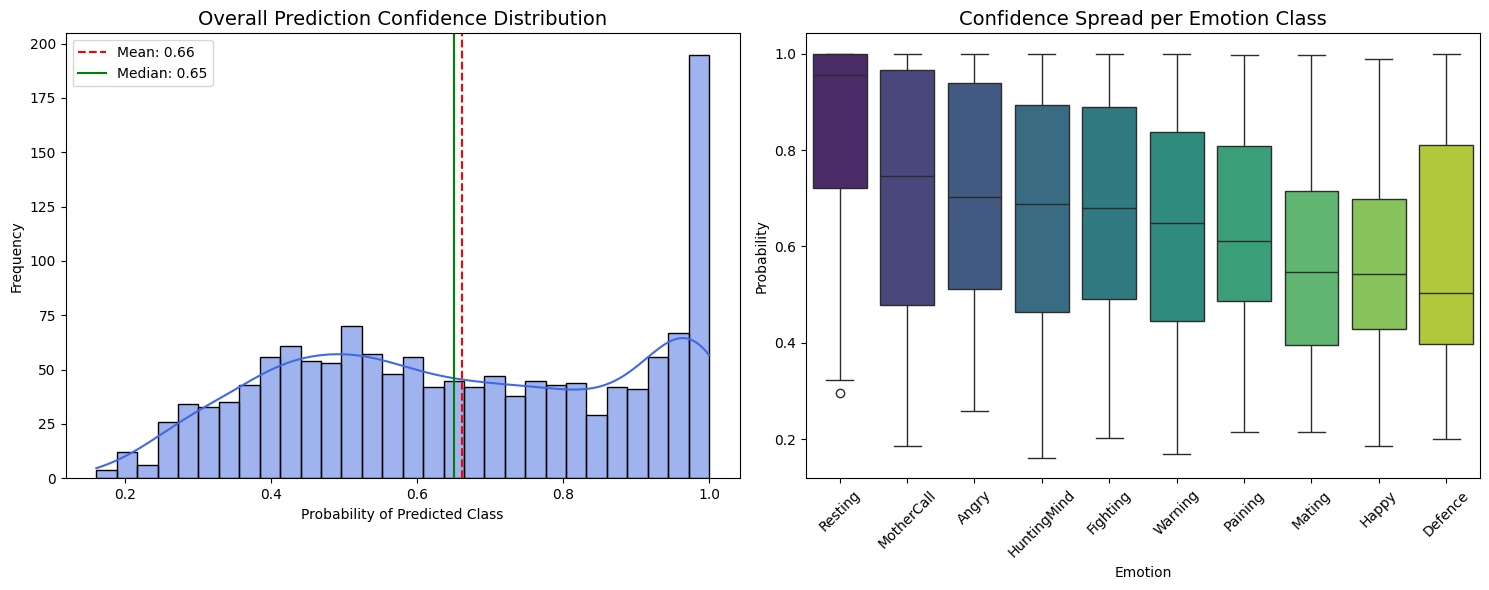

In [15]:
# 1. Prepare the data
# Extract the maximum probability (confidence) for each prediction
confidences = [float(np.max(prob)) for prob in all_probabilities]
labels = [idx_to_class[pred] for pred in all_predictions]

df_probs = pd.DataFrame({
    'Emotion': labels,
    'Confidence': confidences
})

# 2. Create the Visualizations
plt.figure(figsize=(15, 6))

# Plot A: Overall Confidence Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_probs['Confidence'], bins=30, kde=True, color='royalblue')
plt.axvline(df_probs['Confidence'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_probs['Confidence'].mean():.2f}")
plt.axvline(df_probs['Confidence'].median(), color='green', linestyle='-', 
            label=f"Median: {df_probs['Confidence'].median():.2f}")
plt.title('Overall Prediction Confidence Distribution', fontsize=14)
plt.xlabel('Probability of Predicted Class')
plt.ylabel('Frequency')
plt.legend()

# Plot B: Confidence spread per Class (Boxplot)
plt.subplot(1, 2, 2)
# Sorting classes by their median confidence for better readability
class_order = df_probs.groupby('Emotion')['Confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=df_probs, x='Emotion', y='Confidence', order=class_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Confidence Spread per Emotion Class', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

In [16]:
# 3. Print detailed stats
stats = df_probs.groupby('Emotion')['Confidence'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
print("📊 Detailed Confidence Stats per Class:")
print(stats)

📊 Detailed Confidence Stats per Class:
             count      mean       std
Emotion                               
Resting        146  0.849809  0.191951
MotherCall     108  0.706515  0.256822
Angry          135  0.702493  0.232367
HuntingMind    191  0.670839  0.248906
Fighting       121  0.665127  0.223207
Warning        150  0.642806  0.231082
Paining        207  0.640294  0.201430
Defence         63  0.589545  0.251811
Mating         141  0.572478  0.215402
Happy          162  0.566511  0.184383


In [17]:
# 1. Function to extract the deep features (embeddings)
def get_embeddings(model, loader, device='cuda'):
    print("Extracting 2048-D embeddings from the CNN14 backbone...")
    model.eval()
    model.to(device)
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms = waveforms.to(device)
            
            # Instead of calling model(waveforms) which gives the final 10 classes,
            # we call the backbone directly to get the deep features!
            output_dict = model.backbone(waveforms)
            embeddings = output_dict['embedding'] # Shape: (Batch, 2048)
            
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack all batches into one giant numpy array
    return np.vstack(all_embeddings), np.concatenate(all_labels)

In [18]:
# Note: Use the inference_loader we set up (the one with the dummy labels)
embeddings_2048, _ = get_embeddings(cnn14_model, real_loader, device=device)

Extracting 2048-D embeddings from the CNN14 backbone...


In [19]:
# 2. Prepare the labels and confidence for the plot
# We use 'all_predictions' and 'all_probabilities' from your previous inference run
predicted_emotions = [p for p in all_predictions]
confidences = [float(np.max(prob)) for prob in all_probabilities]

print(f"✅ Features ({embeddings_2048.shape}) and Labels ({len(predicted_emotions)}) ready.")

✅ Features ((1424, 2048)) and Labels (1424) ready.


In [20]:
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Running cluster analysis on 1424 samples...

Cluster Quality Metrics (computed in 2048-D space)
--------------------------------------------------
Silhouette Score:           -0.0528  (↑ better, max=1)
Davies-Bouldin Index:       4.8887  (↓ better)
Calinski-Harabasz Score:    17.99  (↑ better)

Per-Class Mean Silhouette:
Angry           : -0.0435
Defence         : -0.2556
Fighting        : -0.1097
Happy           : -0.0517
HuntingMind     : -0.1335
Mating          : 0.1048
MotherCall      : -0.0515
Paining         : 0.0116
Resting         : -0.0311

Running t-SNE projection...


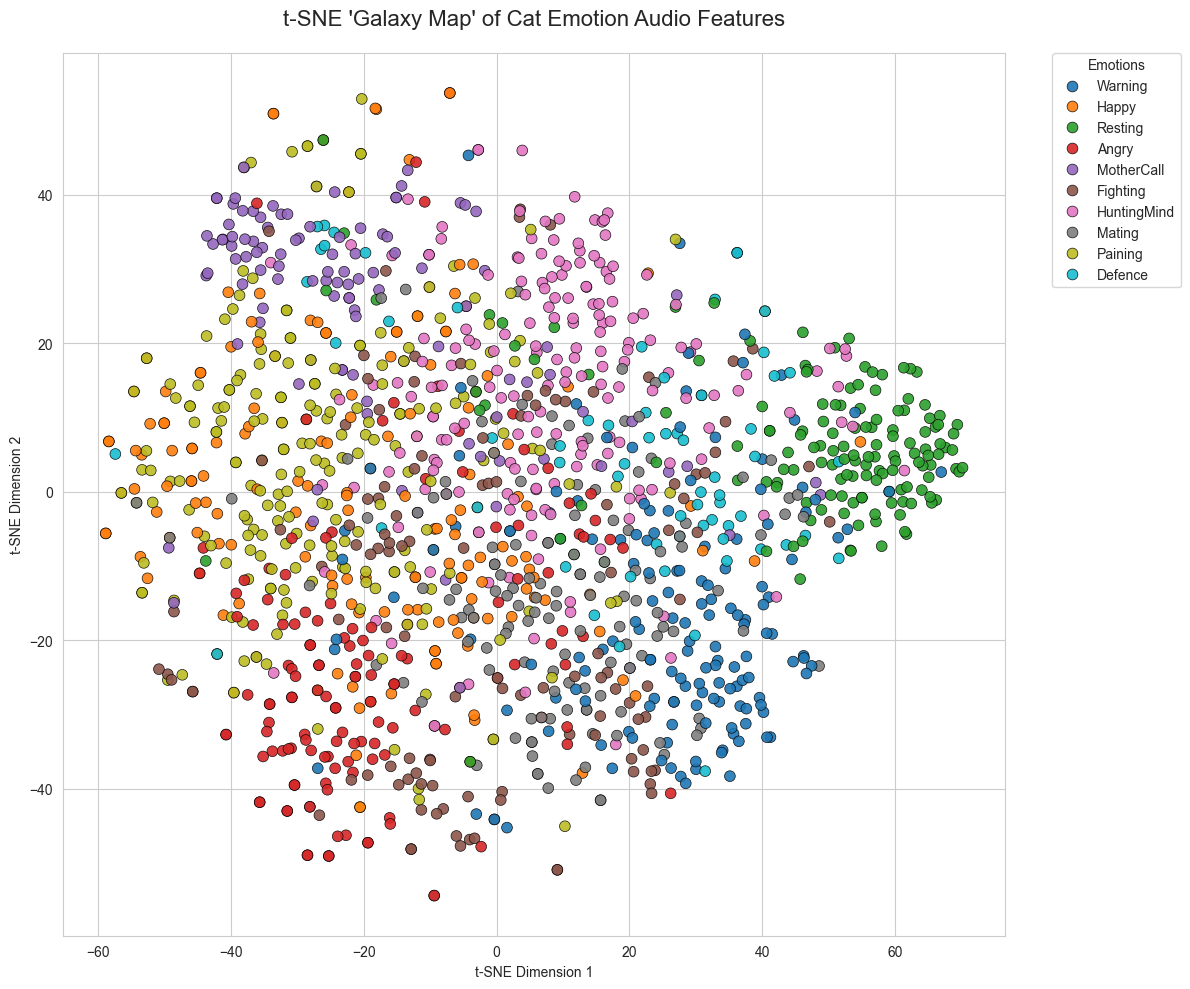

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


def plot_tsne_galaxy_map(embeddings, labels, class_names=None):
    print(f"\nRunning cluster analysis on {embeddings.shape[0]} samples...")

    # --------------------------------------------------
    # 1️⃣ Normalize embeddings (important for distance metrics)
    # --------------------------------------------------
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)

    # --------------------------------------------------
    # 2️⃣ Compute cluster quality metrics (ORIGINAL SPACE)
    # --------------------------------------------------
    sil_score = silhouette_score(embeddings_scaled, labels)
    db_score = davies_bouldin_score(embeddings_scaled, labels)
    ch_score = calinski_harabasz_score(embeddings_scaled, labels)

    print("\nCluster Quality Metrics (computed in 2048-D space)")
    print("--------------------------------------------------")
    print(f"Silhouette Score:           {sil_score:.4f}  (↑ better, max=1)")
    print(f"Davies-Bouldin Index:       {db_score:.4f}  (↓ better)")
    print(f"Calinski-Harabasz Score:    {ch_score:.2f}  (↑ better)")

    # Class-wise silhouette
    sil_samples = silhouette_samples(embeddings_scaled, labels)
    print("\nPer-Class Mean Silhouette:")
    for cls in np.unique(labels):
        cls_mask = labels == cls
        mean_sil = sil_samples[cls_mask].mean()
        name = class_names[cls] if class_names else f"Class {cls}"
        print(f"{name:<15} : {mean_sil:.4f}")

    # --------------------------------------------------
    # 3️⃣ t-SNE Projection (for visualization only)
    # --------------------------------------------------
    print("\nRunning t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(embeddings_scaled)

    if class_names:
        plot_labels = [class_names[label] for label in labels]
    else:
        plot_labels = [f"Class {label}" for label in labels]

    # --------------------------------------------------
    # 4️⃣ Plot
    # --------------------------------------------------
    plt.rcParams.update(plt.rcParamsDefault)
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=plot_labels,
        palette="tab10",
        legend="full",
        alpha=0.9,
        s=60,
        edgecolor='k',
        linewidth=0.5
    )

    plt.title("t-SNE 'Galaxy Map' of Cat Emotion Audio Features", fontsize=16, pad=20)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title="Emotions")

    plt.tight_layout()
    plt.show()

plot_tsne_galaxy_map(embeddings_2048, predicted_emotions, idx_to_class)

## Export predictions (JSONL)

One JSON object per line: `filepath`, `filename`, `predicted_class_idx`, `predicted_class`, `confidence`, and `prob_<emotion>` for each class.


In [23]:
# Export: filepath, filename, predicted class, confidence, and per-class probabilities (JSONL)
import json
from pathlib import Path

n = len(real_dataset.samples)
assert len(all_predictions) == n and len(all_probabilities) == n, (
    len(all_predictions), len(all_probabilities), n
)

rows = []
for i in range(n):
    raw_path = real_dataset.samples[i][0]
    filepath = str(Path(raw_path).resolve())
    filename = os.path.basename(filepath)
    pred_idx = int(all_predictions[i])
    prob = np.asarray(all_probabilities[i], dtype=np.float64)
    row = {
        "filepath": filepath,
        "filename": filename,
        "predicted_class_idx": pred_idx,
        "predicted_class": idx_to_class[pred_idx],
        "confidence": float(prob.max()),
    }
    for j in range(prob.shape[0]):
        row[f"prob_{idx_to_class[j]}"] = float(prob[j])
    rows.append(row)

out_path = Path("human_validation_app/video_audio_human_validation/cat_emotion_predictions.jsonl").resolve()
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
print(f"Saved {len(rows)} lines to {out_path}")


Saved 1424 lines to /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/human_validation_app/video_audio_human_validation/cat_emotion_predictions.jsonl
